In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import torch.nn.functional as F
import numpy as np
from PIL import Image, ImageFilter


class FeatureMapVisualizer:
    def __init__(self, model, target_layer, filter_idx, device='cuda'):
        self.model = model.to(device).eval()
        self.target_layer = target_layer
        self.filter_idx = filter_idx
        self.device = device
        self.activation = None
        self.hook = self.target_layer.register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
        self.activation = output

    def visualize(self, iterations=150, lr=0.1, img_size=224):
        img = np.random.uniform(150, 180, (1, 3, img_size, img_size)) / 255.0
        img_tensor = torch.tensor(img, dtype=torch.float32, device=self.device, requires_grad=True)
        
        optimizer = torch.optim.Adam([img_tensor], lr=lr) # крутим не веса, а яркость пикселей

        for i in range(iterations):
            optimizer.zero_grad()
            
            # двигаем картинку от -16 до 16 пикселей, чтобы искать паттерн везде
            shift_x, shift_y = np.random.randint(-16, 17, 2)
            img_rolled = torch.roll(img_tensor, shifts=(shift_x, shift_y), dims=(2, 3))
            
            self.model(img_rolled)

            # та самая магия с обманом сетки
            loss = -torch.norm(self.activation[0, self.filter_idx]) 
            loss.backward()
            optimizer.step()


            with torch.no_grad():
                img_tensor.clamp_(0, 1)
                if i % 10 == 0:
                    img_tensor.data = F.avg_pool2d(img_tensor, kernel_size=3, stride=1, padding=1)

        self.hook.remove()
        return self.post_process(img_tensor)

    def post_process(self, tensor):
        img = tensor.detach().cpu().squeeze().numpy().transpose(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        return (img * 255).astype(np.uint8)


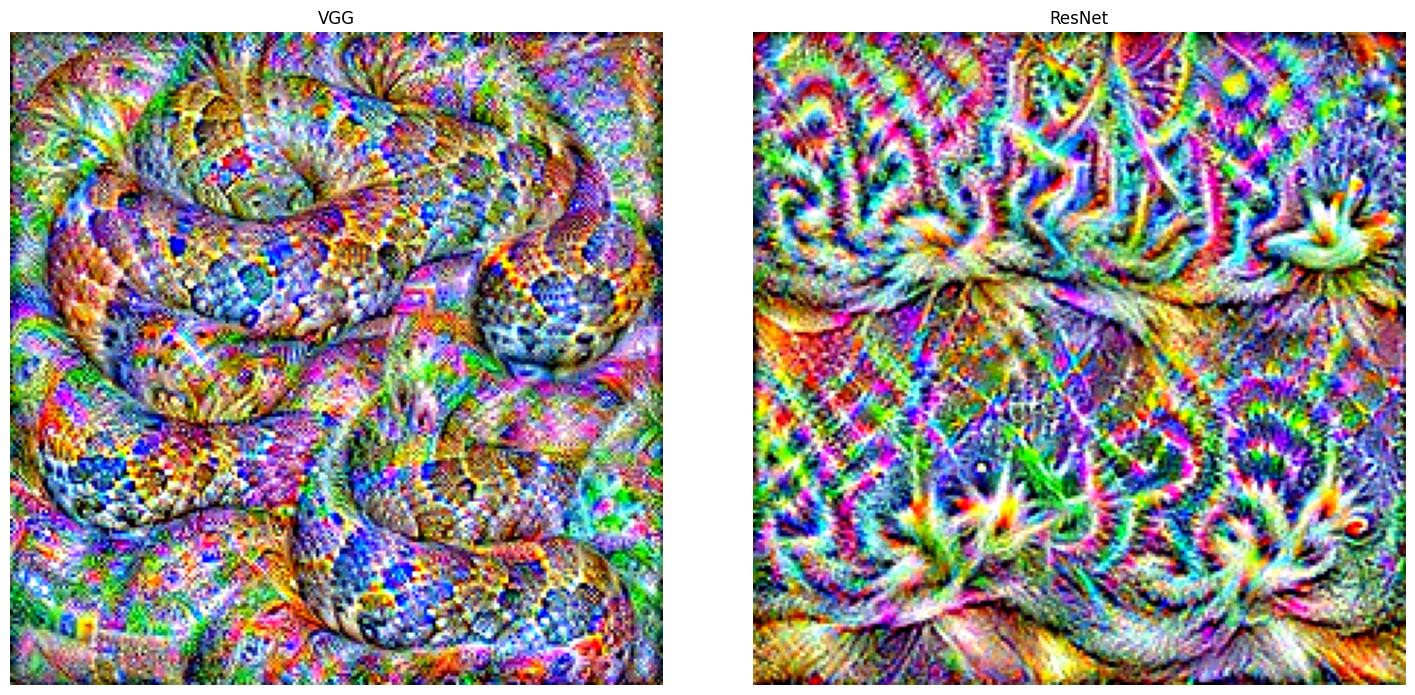

(224, 224, 3)


In [3]:
import matplotlib.pyplot as plt

def show_results(img_vgg, img_resnet, filter_vgg, filter_resnet):
    plt.figure(figsize=(15, 7))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_vgg)
    plt.title("VGG")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_resnet)
    plt.title("ResNet")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

vgg = models.vgg19_bn(weights='IMAGENET1K_V1')
vgg_layer = vgg.features[48]
vis_vgg = FeatureMapVisualizer(vgg, vgg_layer, 91, device)
img_vgg_final = vis_vgg.visualize(iterations=150)

resnet = models.resnet18(weights='IMAGENET1K_V1')
resnet_layer = resnet.layer3[1].conv2 
resnet_filter = 10
vis_resnet = FeatureMapVisualizer(resnet, resnet_layer, resnet_filter, device)
img_resnet_final = vis_resnet.visualize(iterations=150)

show_results(img_vgg_final, img_resnet_final, 91, resnet_filter)
print(img_resnet_final.shape)
